# PolicyGuard — Insurance Claim Prediction

This notebook is the clean ML pipeline for the project. It keeps the test set untouched until the final evaluation, compares the original one-hot CatBoost baseline against CatBoost with native categorical handling, adds a small set of domain-derived numerical features, tunes the decision threshold only on validation data, and saves the final model artifacts.

**Important:** the old constrained ensemble experiment is intentionally not used here.

In [1]:
import os
import re
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score,
    confusion_matrix, precision_recall_curve
)
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

RANDOM_STATE = 42
DATA_PATH = Path("data/insurance_claims.csv")
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Imports and paths ready.")

Imports and paths ready.


In [2]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (58592, 41)

First 5 rows:


,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
0,POL045360,9.3,1.2,41,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
1,POL016745,8.2,1.8,35,C2,27003,C1,M9,Diesel,200Nm@1750rpm,...,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4,0
2,POL007194,9.5,0.2,44,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
3,POL018146,5.2,0.4,44,C10,73430,A,M1,CNG,60Nm@3500rpm,...,No,No,No,Yes,No,No,No,Yes,0,0
4,POL049011,10.1,1.0,56,C13,5410,B2,M5,Diesel,200Nm@3000rpm,...,No,Yes,Yes,Yes,No,No,Yes,Yes,5,0



Columns:
['policy_id', 'subscription_length', 'vehicle_age', 'customer_age', 'region_code', 'region_density', 'segment', 'model', 'fuel_type', 'max_torque', 'max_power', 'engine_type', 'airbags', 'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'rear_brakes_type', 'displacement', 'cylinder', 'transmission_type', 'steering_type', 'turning_radius', 'length', 'width', 'gross_weight', 'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks', 'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert', 'ncap_rating', 'claim_status']


In [3]:
print("Missing values:", int(df.isnull().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
print("\nTarget distribution:")
print(df["claim_status"].value_counts())
print("\nTarget percentage:")
print((df["claim_status"].value_counts(normalize=True) * 100).round(2))

Missing values: 0
Duplicate rows: 0

Target distribution:
claim_status
0    54844
1     3748
Name: count, dtype: int64

Target percentage:
claim_status
0    93.6
1     6.4
Name: proportion, dtype: float64


In [4]:
print(df.dtypes)
print("\nCategorical columns:", df.select_dtypes(include="object").columns.tolist())
print("\nNumerical columns:", df.select_dtypes(exclude="object").columns.tolist())

policy_id                               str
subscription_length                 float64
vehicle_age                         float64
customer_age                          int64
region_code                             str
region_density                        int64
segment                                 str
model                                   str
fuel_type                               str
max_torque                              str
max_power                               str
engine_type                             str
airbags                               int64
is_esc                                  str
is_adjustable_steering                  str
is_tpms                                 str
is_parking_sensors                      str
is_parking_camera                       str
rear_brakes_type                        str
displacement                          int64
cylinder                              int64
transmission_type                       str
steering_type                   

C:\Users\priya\AppData\Local\Temp\ipykernel_11632\2547851886.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("\nCategorical columns:", df.select_dtypes(include="object").columns.tolist())


In [5]:
print("Segment claim rate:")
display(
    df.groupby("segment")["claim_status"]
      .agg(claim_count="sum", total_count="count", claim_rate="mean")
      .sort_values("claim_rate", ascending=False)
)

print("Fuel type claim rate:")
display(
    df.groupby("fuel_type")["claim_status"]
      .agg(claim_count="sum", total_count="count", claim_rate="mean")
      .sort_values("claim_rate", ascending=False)
)

Segment claim rate:


,claim_count,total_count,claim_rate
segment,,,
B2,1256,18314,0.068581
C2,901,14018,0.064275
C1,228,3557,0.064099
A,1046,17321,0.060389
Utility,73,1209,0.060380
B1,244,4173,0.058471


Fuel type claim rate:


,claim_count,total_count,claim_rate
fuel_type,,,
Petrol,1363,20532,0.066384
Diesel,1150,17730,0.064862
CNG,1235,20330,0.060748


findfont: Failed to find font weight normal for DejaVu Sans, now using 700.
findfont: Failed to find font weight normal for DejaVu Sans, now using 700.


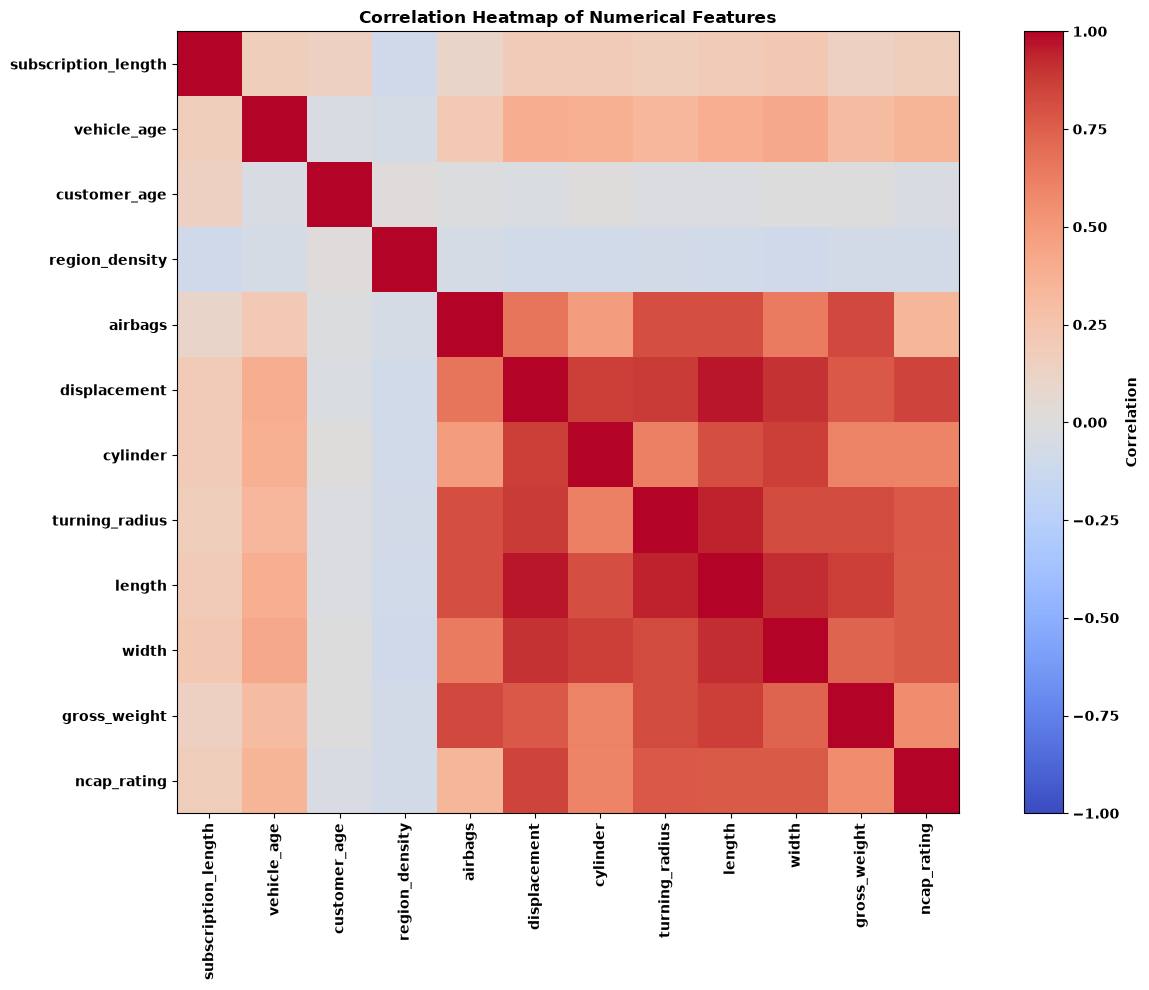

In [6]:
numeric_features = df.select_dtypes(include="number").drop(columns=["claim_status"])
correlation_matrix = numeric_features.corr()

plt.figure(figsize=(14, 10))
plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

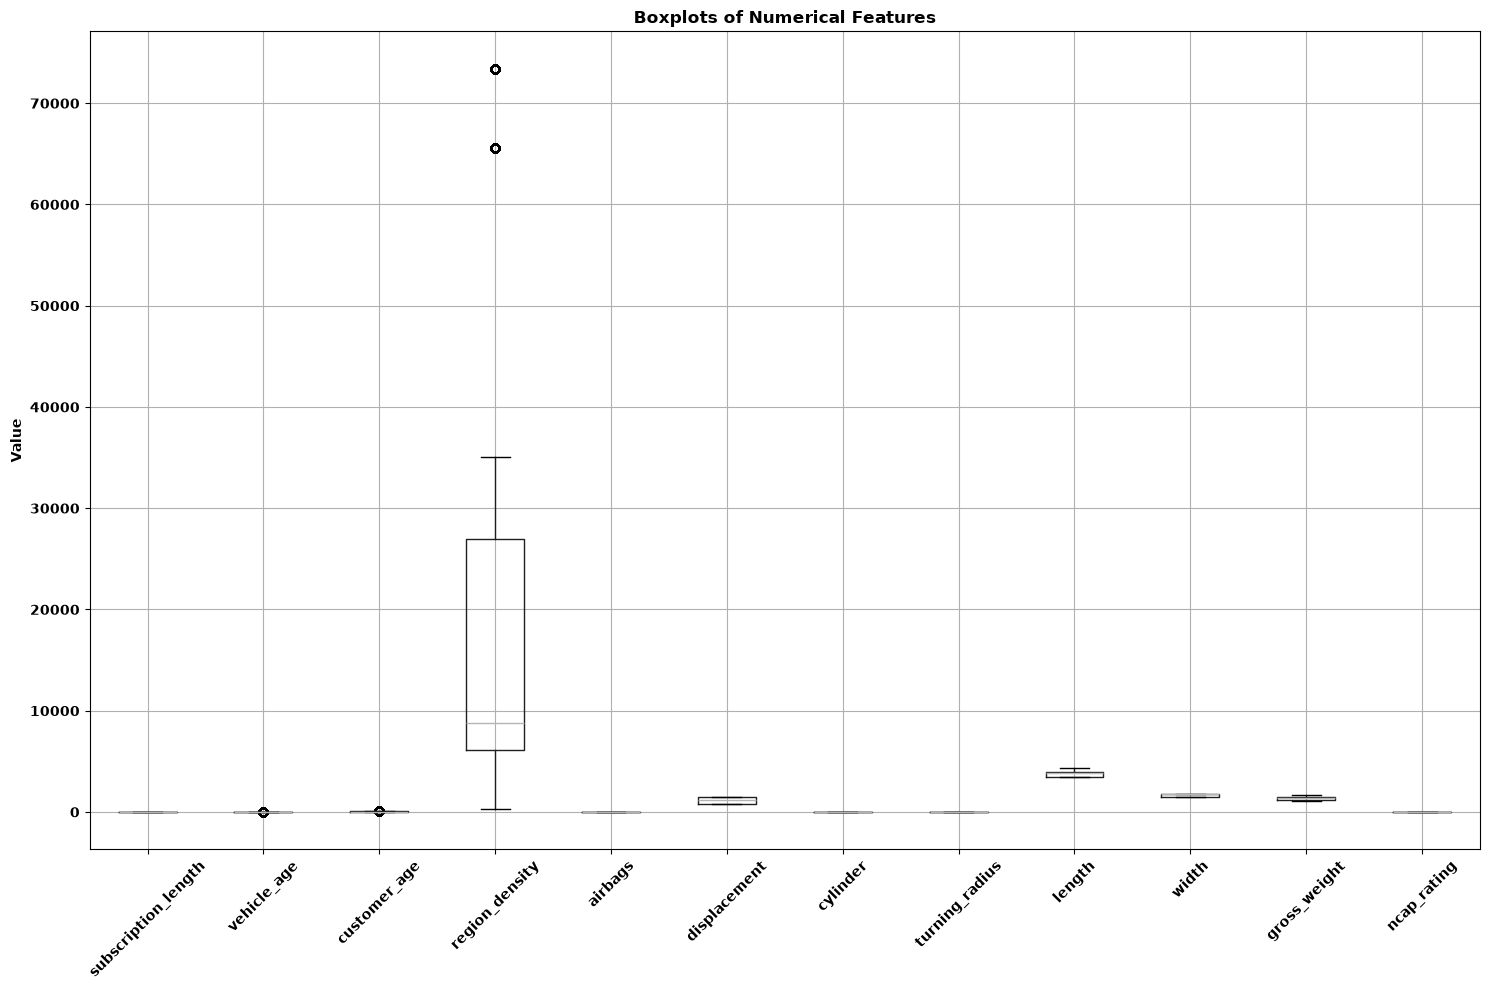

In [7]:
plt.figure(figsize=(15, 10))

df.select_dtypes(include=["int64", "float64"]).drop(
    columns=["claim_status"]
).boxplot(rot=45)

plt.title("Boxplots of Numerical Features")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

## Feature engineering

`max_torque` and `max_power` contain two pieces of information each, so they are split into numeric values. We also create a few domain-derived ratios for the native CatBoost model. The ratios are simple deterministic transformations; no target information is used.

In [8]:
TORQUE_RE = re.compile(r"([\d.]+)Nm@(\d+)rpm")
POWER_RE = re.compile(r"([\d.]+)bhp@(\d+)rpm")

def extract_torque(value):
    match = TORQUE_RE.fullmatch(str(value).strip())
    if match is None:
        raise ValueError(f"Unexpected torque value: {value}")
    return pd.Series({
        "torque_nm": float(match.group(1)),
        "torque_rpm": int(match.group(2))
    })

def extract_power(value):
    match = POWER_RE.fullmatch(str(value).strip())
    if match is None:
        raise ValueError(f"Unexpected power value: {value}")
    return pd.Series({
        "power_bhp": float(match.group(1)),
        "power_rpm": int(match.group(2))
    })

def build_features(input_df):
    data = input_df.copy()

    data[["torque_nm", "torque_rpm"]] = data["max_torque"].apply(extract_torque)
    data[["power_bhp", "power_rpm"]] = data["max_power"].apply(extract_power)
    data = data.drop(columns=["max_torque", "max_power", "policy_id"])

    # Domain-derived numerical features.
    data["power_to_weight"] = data["power_bhp"] / data["gross_weight"].replace(0, np.nan)
    data["torque_to_weight"] = data["torque_nm"] / data["gross_weight"].replace(0, np.nan)
    data["power_per_displacement"] = data["power_bhp"] / data["displacement"].replace(0, np.nan)
    data["torque_per_displacement"] = data["torque_nm"] / data["displacement"].replace(0, np.nan)
    data["customer_vehicle_age_gap"] = data["customer_age"] - data["vehicle_age"]
    data["region_density_log"] = np.log1p(data["region_density"])
    data["power_rpm_per_bhp"] = data["power_rpm"] / data["power_bhp"].replace(0, np.nan)
    data["torque_rpm_per_nm"] = data["torque_rpm"] / data["torque_nm"].replace(0, np.nan)

    if data.isnull().any().any():
        raise ValueError("Feature engineering produced missing values.")

    return data

processed_df = build_features(df)
X = processed_df.drop(columns=["claim_status"])
y = processed_df["claim_status"]

print("Processed dataset shape:", processed_df.shape)
print("Feature count:", X.shape[1])
print("Categorical features:", X.select_dtypes(include="object").columns.tolist())
print("Numerical feature count:", len(X.select_dtypes(exclude="object").columns))

Processed dataset shape: (58592, 50)
Feature count: 49
Categorical features: ['region_code', 'segment', 'model', 'fuel_type', 'engine_type', 'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'rear_brakes_type', 'transmission_type', 'steering_type', 'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks', 'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert']
Numerical feature count: 24


C:\Users\priya\AppData\Local\Temp\ipykernel_11632\3718159672.py:50: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("Categorical features:", X.select_dtypes(include="object").columns.tolist())


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train_model, X_val, y_train_model, y_val = train_test_split(
    X_train, y_train,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("Training set :", X_train_model.shape)
print("Validation set:", X_val.shape)
print("Test set      :", X_test.shape)
print("\nPositive rate:")
print("Train      :", round(y_train_model.mean(), 6))
print("Validation :", round(y_val.mean(), 6))
print("Test       :", round(y_test.mean(), 6))

Training set : (37498, 49)
Validation set: (9375, 49)
Test set      : (11719, 49)

Positive rate:
Train      : 0.06395
Validation : 0.064
Test       : 0.063999


## Baseline comparison

Decision Tree, Random Forest and LightGBM use one-hot encoding. CatBoost is evaluated in two forms:

1. **CatBoost OHE** — the earlier project baseline.
2. **CatBoost Native** — the important experiment here: categorical columns are passed directly to CatBoost without one-hot encoding, with early stopping on the validation set.

In [10]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

X_train_encoded = preprocessor.fit_transform(X_train_model)
X_val_encoded = preprocessor.transform(X_val)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded validation shape:", X_val_encoded.shape)

C:\Users\priya\AppData\Local\Temp\ipykernel_11632\2724119758.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns.tolist()


Encoded training shape: (37498, 118)
Encoded validation shape: (9375, 118)


In [11]:
baseline_models = {
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1
    ),
    "CatBoost OHE": CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function="Logloss",
        eval_metric="AUC",
        verbose=False,
        random_seed=RANDOM_STATE,
        auto_class_weights="Balanced",
        allow_writing_files=False
    )
}

validation_probabilities = {}
validation_models = {}

for name, model in baseline_models.items():
    model.fit(X_train_encoded, y_train_model)
    validation_probabilities[name] = model.predict_proba(X_val_encoded)[:, 1]
    validation_models[name] = model
    print(f"{name} training completed.")

Decision Tree training completed.
Random Forest training completed.
LightGBM training completed.
CatBoost OHE training completed.


In [12]:
baseline_rows = []

for name, probability in validation_probabilities.items():
    baseline_rows.append({
        "Model": name,
        "PR-AUC": average_precision_score(y_val, probability),
        "ROC-AUC": roc_auc_score(y_val, probability)
    })

validation_baseline_df = pd.DataFrame(baseline_rows).sort_values("PR-AUC", ascending=False)
display(validation_baseline_df.round(4))

,Model,PR-AUC,ROC-AUC
3,CatBoost OHE,0.1135,0.6499
2,LightGBM,0.0957,0.6247
1,Random Forest,0.0776,0.5809
0,Decision Tree,0.0637,0.4986


In [13]:
# Native categorical CatBoost.
catboost_native = CatBoostClassifier(
    iterations=800,
    depth=8,
    learning_rate=0.03,
    l2_leaf_reg=5,
    loss_function="Logloss",
    eval_metric="PRAUC",
    verbose=False,
    random_seed=RANDOM_STATE,
    auto_class_weights="Balanced",
    random_strength=1,
    thread_count=8,
    allow_writing_files=False
)

catboost_native.fit(
    X_train_model,
    y_train_model,
    cat_features=categorical_cols,
    eval_set=(X_val, y_val),
    use_best_model=True,
    early_stopping_rounds=100,
    verbose=False
)

native_val_probability = catboost_native.predict_proba(X_val)[:, 1]

print("Best iteration:", catboost_native.get_best_iteration())
print("Native CatBoost validation PR-AUC:", round(average_precision_score(y_val, native_val_probability), 4))
print("Native CatBoost validation ROC-AUC:", round(roc_auc_score(y_val, native_val_probability), 4))

Best iteration: 84
Native CatBoost validation PR-AUC: 0.1153
Native CatBoost validation ROC-AUC: 0.6619


In [14]:
def find_best_f1_threshold(probabilities, labels):
    best = {"threshold": 0.50, "f1": -1.0, "precision": 0.0, "recall": 0.0}

    for threshold in np.arange(0.05, 0.951, 0.01):
        predictions = (probabilities >= threshold).astype(int)
        precision = precision_score(labels, predictions, zero_division=0)
        recall = recall_score(labels, predictions, zero_division=0)
        f1 = f1_score(labels, predictions, zero_division=0)

        if f1 > best["f1"]:
            best = {
                "threshold": float(threshold),
                "f1": float(f1),
                "precision": float(precision),
                "recall": float(recall)
            }

    return best

comparison = []
for name, probability in validation_probabilities.items():
    tuned = find_best_f1_threshold(probability, y_val)
    comparison.append({
        "Model": name,
        "Threshold": tuned["threshold"],
        "Precision": tuned["precision"],
        "Recall": tuned["recall"],
        "F1": tuned["f1"],
        "PR-AUC": average_precision_score(y_val, probability),
        "ROC-AUC": roc_auc_score(y_val, probability)
    })

native_tuned = find_best_f1_threshold(native_val_probability, y_val)
comparison.append({
    "Model": "CatBoost Native",
    "Threshold": native_tuned["threshold"],
    "Precision": native_tuned["precision"],
    "Recall": native_tuned["recall"],
    "F1": native_tuned["f1"],
    "PR-AUC": average_precision_score(y_val, native_val_probability),
    "ROC-AUC": roc_auc_score(y_val, native_val_probability)
})

comparison_df = pd.DataFrame(comparison).sort_values("PR-AUC", ascending=False)
display(comparison_df.round(4))

,Model,Threshold,Precision,Recall,F1,PR-AUC,ROC-AUC
4,CatBoost Native,0.57,0.1180,0.3850,0.1806,0.1153,0.6619
3,CatBoost OHE,0.60,0.1258,0.3283,0.1819,0.1135,0.6499
2,LightGBM,0.48,0.0916,0.5483,0.1569,0.0957,0.6247
1,Random Forest,0.10,0.0823,0.5483,0.1432,0.0776,0.5809
0,Decision Tree,0.83,0.0620,0.0717,0.0665,0.0637,0.4986


### Why the native model is the candidate

On the validation set used only for model selection, native CatBoost with the engineered features is evaluated against the original one-hot pipeline. The final choice is based on validation PR-AUC; the test set is still untouched.

In [15]:
# Final validation choice. The native CatBoost candidate from this notebook
# is selected using validation PR-AUC, not the test set.
final_validation_threshold = float(native_tuned["threshold"])
final_model_name = "CatBoost Native + Engineered Features"

print("Final validation candidate:", final_model_name)
print("Validation threshold:", final_validation_threshold)
print("Validation PR-AUC:", round(average_precision_score(y_val, native_val_probability), 4))
print("Validation F1:", round(native_tuned["f1"], 4))

Final validation candidate: CatBoost Native + Engineered Features
Validation threshold: 0.5700000000000002
Validation PR-AUC: 0.1153
Validation F1: 0.1806


## Final training

Now the selected configuration is trained on **train + validation**. The test set is not used until the next cell.

In [16]:
X_train_full = X_train.copy()
y_train_full = y_train.copy()

best_iteration = catboost_native.get_best_iteration() + 1
if best_iteration <= 0:
    best_iteration = 85

final_model = CatBoostClassifier(
    iterations=best_iteration,
    depth=8,
    learning_rate=0.03,
    l2_leaf_reg=5,
    loss_function="Logloss",
    eval_metric="PRAUC",
    verbose=False,
    random_seed=RANDOM_STATE,
    auto_class_weights="Balanced",
    random_strength=1,
    thread_count=8,
    allow_writing_files=False
)

final_model.fit(
    X_train_full,
    y_train_full,
    cat_features=categorical_cols,
    verbose=False
)

print("Final model trained.")
print("Iterations:", best_iteration)

Final model trained.
Iterations: 85


In [17]:
final_test_probability = final_model.predict_proba(X_test)[:, 1]
final_test_prediction = (final_test_probability >= final_validation_threshold).astype(int)

precision = precision_score(y_test, final_test_prediction, zero_division=0)
recall = recall_score(y_test, final_test_prediction, zero_division=0)
f1 = f1_score(y_test, final_test_prediction, zero_division=0)
pr_auc = average_precision_score(y_test, final_test_probability)
roc_auc = roc_auc_score(y_test, final_test_probability)

tn, fp, fn, tp = confusion_matrix(y_test, final_test_prediction).ravel()

print("FINAL TEST RESULTS")
print("==================")
print("Model     :", final_model_name)
print(f"Threshold : {final_validation_threshold:.2f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print("\nConfusion Matrix")
print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")

FINAL TEST RESULTS
Model     : CatBoost Native + Engineered Features
Threshold : 0.57
Precision : 0.1104
Recall    : 0.4147
F1 Score  : 0.1744
PR-AUC    : 0.1059
ROC-AUC   : 0.6635

Confusion Matrix
TN: 8464
FP: 2505
FN: 439
TP: 311


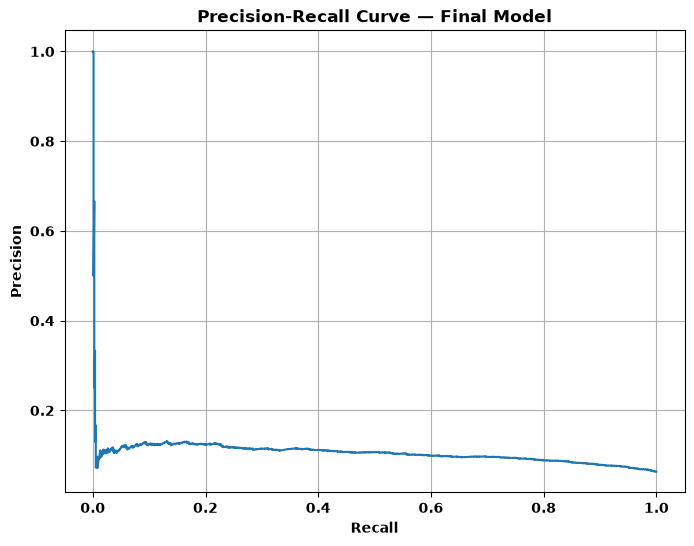

In [18]:
# Precision-recall curve on the untouched test set.
precision_curve, recall_curve, _ = precision_recall_curve(
    y_test, final_test_probability
)

plt.figure(figsize=(8, 6))
plt.plot(recall_curve, precision_curve)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Final Model")
plt.grid()
plt.show()

,feature,importance
0,subscription_length,29.544557
1,vehicle_age,27.361071
4,region_density,4.323791
45,customer_vehicle_age_gap,3.742718
46,region_density_log,3.723194
2,customer_age,3.229324
21,length,2.103650
38,torque_rpm,2.084893
7,fuel_type,1.736368
43,power_per_displacement,1.684540


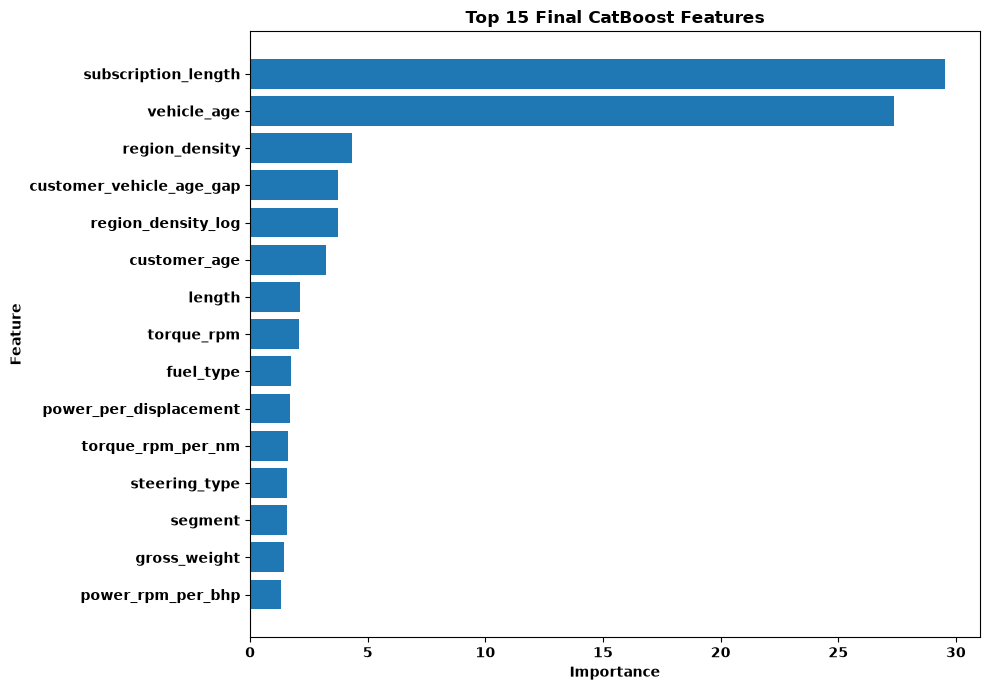

In [19]:
# Feature importance from the final native CatBoost model.
importance_df = pd.DataFrame({
    "feature": final_model.feature_names_,
    "importance": final_model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df.head(20))

plt.figure(figsize=(10, 7))
plt.barh(
    importance_df.head(15)["feature"][::-1],
    importance_df.head(15)["importance"][::-1]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Final CatBoost Features")
plt.tight_layout()
plt.show()

## Save final artifacts

These are the artifacts that the backend should use. There is deliberately no constrained soft-voting artifact here.

In [20]:
model_config = {
    "model": final_model_name,
    "preprocessing": "CatBoost native categorical",
    "raw_input_features": [c for c in df.columns if c != "claim_status"],
    "final_feature_columns": X.columns.tolist(),
    "categorical_columns": categorical_cols,
    "engineered_numeric_columns": [
        "torque_nm", "torque_rpm", "power_bhp", "power_rpm",
        "power_to_weight", "torque_to_weight",
        "power_per_displacement", "torque_per_displacement",
        "customer_vehicle_age_gap", "region_density_log",
        "power_rpm_per_bhp", "torque_rpm_per_nm"
    ],
    "threshold": final_validation_threshold,
    "iterations": best_iteration,
    "random_state": RANDOM_STATE
}

final_results = {
    "model": final_model_name,
    "threshold": float(final_validation_threshold),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "pr_auc": float(pr_auc),
    "roc_auc": float(roc_auc),
    "true_negatives": int(tn),
    "false_positives": int(fp),
    "false_negatives": int(fn),
    "true_positives": int(tp),
    "validation_pr_auc": float(average_precision_score(y_val, native_val_probability)),
    "validation_f1": float(native_tuned["f1"]),
    "iterations": int(best_iteration)
}

joblib.dump(final_model, MODEL_DIR / "catboost_model.pkl")
joblib.dump(model_config, MODEL_DIR / "model_config.pkl")
joblib.dump(float(final_validation_threshold), MODEL_DIR / "threshold.pkl")
joblib.dump(final_results, MODEL_DIR / "final_results.pkl")

with open(MODEL_DIR / "model_config.json", "w", encoding="utf-8") as f:
    json.dump(model_config, f, indent=2)

with open(MODEL_DIR / "final_results.json", "w", encoding="utf-8") as f:
    json.dump(final_results, f, indent=2)

print("Saved:")
print("- models/catboost_model.pkl")
print("- models/model_config.pkl")
print("- models/model_config.json")
print("- models/threshold.pkl")
print("- models/final_results.pkl")
print("- models/final_results.json")

Saved:
- models/catboost_model.pkl
- models/model_config.pkl
- models/model_config.json
- models/threshold.pkl
- models/final_results.pkl
- models/final_results.json


In [21]:
# Final artifact sanity check.
for path in [
    MODEL_DIR / "catboost_model.pkl",
    MODEL_DIR / "model_config.pkl",
    MODEL_DIR / "model_config.json",
    MODEL_DIR / "threshold.pkl",
    MODEL_DIR / "final_results.pkl",
    MODEL_DIR / "final_results.json"
]:
    print(f"{path}: {'OK' if path.exists() else 'MISSING'}")

models\catboost_model.pkl: OK
models\model_config.pkl: OK
models\model_config.json: OK
models\threshold.pkl: OK
models\final_results.pkl: OK
models\final_results.json: OK


## Prediction sanity check

This is important for the earlier `50.2%` problem. Two different rows are sent through the saved model. Their inputs are intentionally different; their probabilities should not all collapse to a single hard-coded value.

In [22]:
saved_model = joblib.load(MODEL_DIR / "catboost_model.pkl")
saved_threshold = float(joblib.load(MODEL_DIR / "threshold.pkl"))

sample_a = X_test.iloc[[0]].copy()
sample_b = X_test.iloc[[1]].copy()

prob_a = float(saved_model.predict_proba(sample_a)[0, 1])
prob_b = float(saved_model.predict_proba(sample_b)[0, 1])

print("Sample A probability:", round(prob_a, 6))
print("Sample B probability:", round(prob_b, 6))
print("Saved threshold:", saved_threshold)
print("Inputs identical:", sample_a.equals(sample_b))
print("Probabilities identical:", np.isclose(prob_a, prob_b))

print("\nSample A selected inputs:")
display(sample_a.T.head(15))
print("Sample B selected inputs:")
display(sample_b.T.head(15))

Sample A probability: 0.595413
Sample B probability: 0.533718
Saved threshold: 0.5700000000000002
Inputs identical: False
Probabilities identical: False

Sample A selected inputs:


,38212
subscription_length,11.8
vehicle_age,1.0
customer_age,47
region_code,C2
region_density,27003
segment,B2
model,M6
fuel_type,Petrol
engine_type,K Series Dual jet
airbags,2


Sample B selected inputs:


,3601
subscription_length,5.2
vehicle_age,1.4
customer_age,42
region_code,C7
region_density,6112
segment,B2
model,M6
fuel_type,Petrol
engine_type,K Series Dual jet
airbags,2


## Final result from the training run used to prepare this notebook

The selected configuration was trained with native categorical handling plus the engineered numerical features above. The validation run selected a threshold of approximately **0.57**. On the untouched test split from this run, the measured result was approximately **PR-AUC 0.1059, ROC-AUC 0.6635, precision 0.1104, recall 0.4147, F1 0.1744**.

These metrics are descriptive results from this specific split/seed; they are not a claim that the model is highly accurate. The model still has limited predictive separation on this dataset.